In [39]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

# sparse_output=False: resultaat na encoding is normale NumPy array
encoder = OneHotEncoder(sparse_output=False)

# Load mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# train_images = train_images[:, ::2, ::2]
# test_images = test_images[:, ::2, ::2]

# Normalize images
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

train_images_flat = train_images.reshape(-1, 784)
test_images_flat = test_images.reshape(-1, 784)

# One hot encode labels
train_labels_oh = encoder.fit_transform(train_labels.reshape(-1, 1))
test_labels_oh = encoder.fit_transform(test_labels.reshape(-1, 1))


<function matplotlib.pyplot.show(close=None, block=None)>

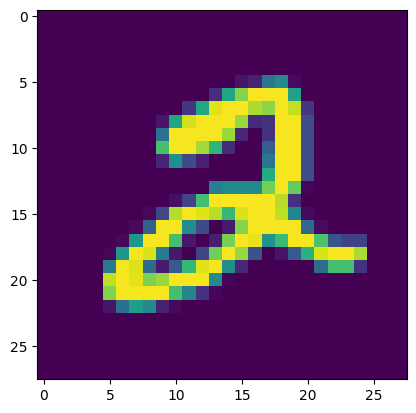

In [40]:
plt.imshow(train_images[5])
plt.show

In [41]:
print(train_images_flat.shape)
print(test_images_flat.shape)

(60000, 784)
(10000, 784)


In [42]:
def relu(arr):
    return np.maximum(0, arr)

def softmax(arr):
    arr = np.array(arr, dtype=np.float64)
    shifted = arr - np.max(arr, axis=-1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=-1, keepdims=True)

testdata = np.array([-2.0, -0.5, 0.0, 1.5, 3.0])
batch = np.array([
    [1.0, 2.0, 3.0],
    [1.0, 0.0, -1.0]
])


print(relu(testdata))
print(softmax(batch))

print("Sum of softmax outputs for each row:")
for i in range(len(batch)):
    print(f"Row {i}: {sum(softmax(batch)[i])}")


[0.  0.  0.  1.5 3. ]
[[0.09003057 0.24472847 0.66524096]
 [0.66524096 0.24472847 0.09003057]]
Sum of softmax outputs for each row:
Row 0: 0.9999999999999999
Row 1: 0.9999999999999999


In [43]:
y_true = np.array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]])
y_pred = np.array([[0.01, 0.02, 0.01, 0.05, 0.03, 0.02, 0.04, 0.75, 0.05, 0.02]])

def cross_entropy(y_true, y_predicted):
    e = 1e-9 # kleine waarde om log(0) te voorkomen
    return -np.mean(np.sum(y_true * np.log(y_predicted + e), axis=1))


ce_1 = cross_entropy(y_true, y_pred)
print(ce_1)


0.2876820711184476


In [61]:
input_nodes_amount = 784
hidden_nodes_amount = 128
output_nodes_amount = 10

W1 = np.array(np.random.randn(input_nodes_amount, hidden_nodes_amount) * 0.01, dtype="float16")
b1 = np.zeros(hidden_nodes_amount)

W2 = np.array(np.random.randn(hidden_nodes_amount, output_nodes_amount) * 0.01, dtype="float64")
b2 = np.zeros(output_nodes_amount)

In [62]:
print(f"size kb: {(W1.nbytes + W2.nbytes + b1.nbytes + b2.nbytes)/1000}")

size kb: 212.048


In [46]:
def forward(X, weight1, bias1, weight2, bias2):
    Z1 = X @ weight1 + bias1
    A1 = relu(Z1)
    Z2 = A1 @ weight2 + bias2
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return (A2, cache)

input_data = train_images_flat[:5]
actual_labels = train_labels_oh[:5]

pred, cache = forward(input_data, W1, b1, W2, b2)


print(actual_labels)
# print(pred.shape)
print(pred)
# print(cache)

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0.10015237 0.09970986 0.09983327 0.09985431 0.10010633 0.09983873
  0.09995373 0.10021529 0.10006835 0.10026776]
 [0.10056499 0.10020437 0.09954    0.09924595 0.10045919 0.09956138
  0.09959772 0.10015063 0.10029715 0.10037863]
 [0.10008677 0.10022466 0.09963703 0.09925402 0.10044911 0.10007313
  0.1001691  0.10017107 0.10003872 0.09989639]
 [0.09971382 0.09996283 0.09927958 0.09975328 0.10053862 0.10004176
  0.10014624 0.10014063 0.10048349 0.09993975]
 [0.10023947 0.09992397 0.09946407 0.09926703 0.10052871 0.10020286
  0.10005575 0.1000412  0.10001414 0.1002628 ]]


In [47]:
def compute_output_gradient(final_prediction, correct_answers):
    N = final_prediction.shape[0] # aantal plaatjes pet batch
    # print(f"Batch size: {N}")
    return (final_prediction - correct_answers) / N

compute_output_gradient(pred, actual_labels)

array([[ 0.02003047,  0.01994197,  0.01996665,  0.01997086,  0.02002127,
        -0.18003225,  0.01999075,  0.02004306,  0.02001367,  0.02005355],
       [-0.179887  ,  0.02004087,  0.019908  ,  0.01984919,  0.02009184,
         0.01991228,  0.01991954,  0.02003013,  0.02005943,  0.02007573],
       [ 0.02001735,  0.02004493,  0.01992741,  0.0198508 , -0.17991018,
         0.02001463,  0.02003382,  0.02003421,  0.02000774,  0.01997928],
       [ 0.01994276, -0.18000743,  0.01985592,  0.01995066,  0.02010772,
         0.02000835,  0.02002925,  0.02002813,  0.0200967 ,  0.01998795],
       [ 0.02004789,  0.01998479,  0.01989281,  0.01985341,  0.02010574,
         0.02004057,  0.02001115,  0.02000824,  0.02000283, -0.17994744]])

In [48]:
def compute_output_gradients(hidden_output, output_gradient):
    dW2 = hidden_output.T @ output_gradient
    db2 = np.sum(output_gradient, axis=0)
    return (dW2, db2)

dw2, db2 = compute_output_gradients(cache[2], compute_output_gradient(pred, actual_labels))

print("dW2 shape:", dw2.shape)
print("db2 shape:", db2.shape)

dW2 shape: (64, 10)
db2 shape: (10,)


In [49]:
def compute_hidden_gradient(output_gradient, hidden_to_output_weights):
    return output_gradient @ hidden_to_output_weights.T

In [50]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [51]:
def compute_hidden_gradients(hidden_gradient, hidden_raw_gradient, input_data):
    dZ1 = hidden_gradient * relu_derivative(hidden_raw_gradient)

    dW1 = input_data.T @ dZ1
    db1 = np.sum(dZ1, axis=0)
    return (dW1, db1)

In [52]:
def backward(y_true, cache, W2):
    # Tussenwaarden uit de forward pass uitpakken
    X, Z1, A1, Z2, A2 = cache

    # Fout bij de output: voorspelling - juiste antwoord (gemiddeld over de batch)
    output_gradient = compute_output_gradient(A2, y_true)

    # Gradient van output-gewichten W2 en bias b2
    dW2, db2 = compute_output_gradients(A1, output_gradient)

    # Foutsignaal terugsturen naar de hidden-laag via W2
    hidden_gradient = compute_hidden_gradient(output_gradient, W2)

    # Gradient van hidden-gewichten W1 en bias b1 (relu-afgeleide blokkeert inactieve nodes)
    dW1, db1 = compute_hidden_gradients(hidden_gradient, Z1, X)

    # Alle vier de gradienten teruggeven voor de update-stap
    return (dW1, db1, dW2, db2)

In [70]:
lr = 0.01
batch_size = 256
n = train_images_flat.shape[0]
epochs = 1000

print(f"Number of training samples: {n}")

for epoch in range(epochs):

    # train in batches van batch_size
    for start in range(0, n, batch_size):
        b = slice(start, start + batch_size)
        voorspelling, cache = forward(train_images_flat[b], W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(train_labels_oh[b], cache, W2)
        W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2

    # einde epoch: loss/acc op de hele set
    pred_all, _ = forward(train_images_flat, W1, b1, W2, b2)
    loss = cross_entropy(train_labels_oh, pred_all)
    acc = np.mean(np.argmax(pred_all, axis=1) == train_labels)
    print(f"Epoch {epoch + 1}, Loss: {loss:.4f}, Acc: {acc:.3f}")

Number of training samples: 60000
Epoch 1, Loss: 0.0634, Acc: 0.984
Epoch 2, Loss: 0.0632, Acc: 0.984
Epoch 3, Loss: 0.0631, Acc: 0.984
Epoch 4, Loss: 0.0630, Acc: 0.984
Epoch 5, Loss: 0.0629, Acc: 0.984
Epoch 6, Loss: 0.0627, Acc: 0.984
Epoch 7, Loss: 0.0626, Acc: 0.984
Epoch 8, Loss: 0.0625, Acc: 0.984
Epoch 9, Loss: 0.0624, Acc: 0.984
Epoch 10, Loss: 0.0622, Acc: 0.984
Epoch 11, Loss: 0.0621, Acc: 0.984
Epoch 12, Loss: 0.0620, Acc: 0.984
Epoch 13, Loss: 0.0619, Acc: 0.984
Epoch 14, Loss: 0.0617, Acc: 0.985
Epoch 15, Loss: 0.0616, Acc: 0.985
Epoch 16, Loss: 0.0615, Acc: 0.985
Epoch 17, Loss: 0.0614, Acc: 0.985
Epoch 18, Loss: 0.0613, Acc: 0.985
Epoch 19, Loss: 0.0611, Acc: 0.985
Epoch 20, Loss: 0.0610, Acc: 0.985
Epoch 21, Loss: 0.0609, Acc: 0.985
Epoch 22, Loss: 0.0608, Acc: 0.985
Epoch 23, Loss: 0.0607, Acc: 0.985
Epoch 24, Loss: 0.0606, Acc: 0.985
Epoch 25, Loss: 0.0604, Acc: 0.985
Epoch 26, Loss: 0.0603, Acc: 0.985
Epoch 27, Loss: 0.0602, Acc: 0.985
Epoch 28, Loss: 0.0601, Acc: 0

KeyboardInterrupt: 

In [71]:
test_pred, _ = forward(test_images_flat, W1, b1, W2, b2)

test_loss = cross_entropy(test_labels_oh, test_pred)
test_acc = np.mean(np.argmax(test_pred, axis=1) == test_labels)

print("Final evaluation:")
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.3f}")

Final evaluation:
Test loss: 0.0845, Test accuracy: 0.974


In [72]:
# Export weights
destination = input("Desitination path")
np.save(destination + "W1.npy", W1, True)
np.save(destination + "b1.npy", b1, True)
np.save(destination + "W2.npy", W2, True)
np.save(destination + "b2.npy", b2, True)